<a href="https://colab.research.google.com/github/JungYeoni/study_torch/blob/main/%ED%8C%8C%EC%9D%B4%ED%86%A0%EC%B9%98_%EA%B8%B0%EC%B4%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 텐서 조작하기

학습자료
> https://wikidocs.net/52460

## 파이토치 패키지의 기본 구성

- `torch`: 메인 네임스페이스, 텐서 등의 다양한 수학 함수가 포함되어있음. Numpy와 유사한 구조
- `torch.autograd`: 자동 미분을 위한 함수들이 포함되어 있음.
- `torch.nn`: 신경망을 구축하기 위한 다양한 데이터 구조나 레이어들이 정의되어져 있음.
  - RNN, LSTM 같은 레이어
  - ReLU 와 같은 활성화 함수
  - MSELoss 와 같은 손실 함수 등
- `torch.optim`: SGD를 중심으로 한 파라미터 최적화 알고리즘이 구현되어 있음.
- `torch.utils.data`: SGD의 반복 연산을 실행할 때 사용하는 미니 배치용 유틸리티 함수 포함
- `torch.onnx`: ONNX(Open Neural Network Exchange)의 포멧으로 모델을 익스포트 할 때 사용  
  -> 서로 다른 딥러닝 프레임워크 간에 모델을 공유할 때 사용

## 넘파이로 텐서 만들기

In [2]:
import numpy as np

## 1) 1D with Numpy

In [9]:
t = np.array([0., 1., 2.,  3., 4., 5., 6.]) # List를 생성해서 np.array로 1차원 array로 변환
print(t)

[0. 1. 2. 3. 4. 5. 6.]


In [6]:
# 벡터의 차원과 크기 출력
print('Rank of t:', t.ndim)
print('Shape of t:', t.shape)

Rank of t: 1
Shape of t: (7,)


### 1-1) Numpy 기초 이해하기

- Numpy에서 각 벡터의 원소에 접근하는 방법

In [8]:
# 인덱스로 지정하기
print('t[0] t[1] t[-1] = ', t[0], t[1], t[-1])

t[0] t[1] t[-1] =  0.0 1.0 6.0


In [10]:
# 슬라이싱으로 지정하기
print('t[2:5] t[4:-1] = ', t[2:5], t[4:-1])

t[2:5] t[4:-1] =  [2. 3. 4.] [4. 5.]


In [11]:
# 시작 번호를 생략한 경우
print('t[:2] = ', t[:2])

t[:2] [0. 1.]


In [13]:
# 끝 번호를 생략한 경우
print('t[3:] = ', t[3:])

t[3:] =  [3. 4. 5. 6.]


## 2) 2D with Numpy

In [14]:
# Numpy로 2차원 행렬 만들기
t = np.array([
    [1., 2., 3.],
    [4., 5., 6.],
    [7., 8., 9],
    [10., 11., 12.]
])

print(t)

[[ 1.  2.  3.]
 [ 4.  5.  6.]
 [ 7.  8.  9.]
 [10. 11. 12.]]


In [15]:
# 차원과 크기 출력
print('Rank of t:', t.ndim)
print('Shape of t:', t.shape)

Rank of t: 2
Shape of t: (4, 3)


## 파이토치 선언하기
- Numpy로 했던 실습을 파이토치로 실습해보기

In [16]:
import torch

### 1) 1D with PyTorch

In [18]:
t = torch.FloatTensor([0., 1., 2., 3., 4., 5., 6.])
print(t)

tensor([0., 1., 2., 3., 4., 5., 6.])


In [19]:
print(t.dim())
print(t.shape)
print(t.size())

1
torch.Size([7])
torch.Size([7])


In [23]:
print(t[0], t[1], t[-1]) # 인덱스로 접근
print(t[2:5], t[4:-1]) # 슬라이싱
print(t[:2], t[3:]) # 슬라이싱 (첫 번째/마지막 인자 생략)

tensor(0.) tensor(1.) tensor(6.)
tensor([2., 3., 4.]) tensor([4., 5.])
tensor([0., 1.]) tensor([3., 4., 5., 6.])


### 2) 2D with Pytorch

In [24]:
# 파이토치로 2차원 텐서(행렬) 생성하기
t = torch.FloatTensor([
    [1., 2., 3.],
    [4., 5., 6.],
    [7., 8., 9],
    [10., 11., 12.]
])

print(t)

tensor([[ 1.,  2.,  3.],
        [ 4.,  5.,  6.],
        [ 7.,  8.,  9.],
        [10., 11., 12.]])


In [25]:
print(t.dim())
print(t.size())

2
torch.Size([4, 3])


In [31]:
print(t[:, 1]) # 첫번째 차원을 전체 선택한 상황에서 두번째 차원의 첫번째 것만 가져온다.
print(t[:, 1].size())

tensor([ 2.,  5.,  8., 11.])
torch.Size([4])


In [33]:
print(t[:, :-1]) # 첫번째 차원을 전체 선택한 상황에서 두번째 차원에서는 맨 마지막 첫 번쨎를 제외하고 다 가져온다.
print(t[:, :-1].shape)

tensor([[ 1.,  2.],
        [ 4.,  5.],
        [ 7.,  8.],
        [10., 11.]])
torch.Size([4, 2])


### 3) 브로드캐스팅(Broadcasting)
- 크기가 다른 행렬 또는 텐서에 대해서 사칙 연산을 수행할 때 자동으로 크기를 맞춰서 연산을 수행하게 만드는 기능

In [36]:
# 같은 크기일 때
m1 = torch.FloatTensor([
    [3, 3]
])

m2 = torch.FloatTensor([
    [2, 2]
])

print(m1 + m2)

tensor([[5., 5.]])


In [38]:
# 다른 크기일 때

# 2 x 1 vector
m1 = torch.FloatTensor([
    [1, 2]
])

# 1 x 2 vector
m2 = torch.FloatTensor([
    [3],
    [4]
])

print(m1 + m2)

tensor([[4., 5.],
        [5., 6.]])


브로드캐스팅 과정에서 실제로 두 텐서가 어떻게 변경되는지 확인해보기

[1, 2]

==> [[1, 2],  
    [1, 2]]

[3]  
[4]

==> [[3, 3],  
    [4, 4]]

! 주의
- 브로드캐스팅은 자동으로 수행되므로 나중에 원하는 결과가 나오지 않았더라도 어디서 문제가 발생하는지 찾기 어려울 수 있음

### 4) 자주 사용되는 기능들

1) 행렬 곱셈과 곱셈의 차이

In [40]:
m1 = torch.FloatTensor([
    [1, 2],
    [3, 4]
])

m2 = torch.FloatTensor([
    [1],
    [2]
])

print('Shape of Matrix 1:', m1.shape)
print('Shape of Matrix 2:', m2.shape)
print(m1.matmul(m2))

Shape of Matrix 1: torch.Size([2, 2])
Shape of Matrix 2: torch.Size([2, 1])
tensor([[ 5.],
        [11.]])


- 위의 결과는 2x2 행렬과 2x1 행렬(벡터)의 행렬 곱셈의 결과를 보여줌

element-wise 곱셈
- 동일한 크기의 행렬이 동일한 위치에 있는 원소끼리 곱하는 것
- 브로드캐스팅이 된 후에 곱셈이 수행됨

In [41]:
m1 = torch.FloatTensor([
    [1, 2],
    [3, 4]
])

m2 = torch.FloatTensor([
    [1],
    [2]
])

print('Shape of Matrix 1:', m1.shape)
print('Shape of Matrix 2:', m2.shape)

# element-wise 곱셈 수행하기
print(m1 * m2) # 2x2
print(m1.mul(m2))

Shape of Matrix 1: torch.Size([2, 2])
Shape of Matrix 2: torch.Size([2, 1])
tensor([[1., 2.],
        [6., 8.]])
tensor([[1., 2.],
        [6., 8.]])


2. 평균(Mean)

In [42]:
# 1차원 벡터 선언
t = torch.FloatTensor([1, 2])
print(t.mean())

tensor(1.5000)


In [43]:
# 2차원 행렬 선언
t = torch.FloatTensor([
    [1, 2],
    [3, 4]
])
print(t)

tensor([[1., 2.],
        [3., 4.]])


In [44]:
print(t.mean()) # 4개 원소의 펻균 출력

tensor(2.5000)


차원을 인자로 주는 경우
- 해당 차원을 제거한다는 의미
- `dim=0`은 행렬에서 열만 남기겠다는 의미 --> 열의 차원만 보존한다.
- `dim=1`은 행렬에서 행만 남기겠다는 의미 --> 행의 차원만 보존한다.
- `dim=-1`은 마지막 차원을 제거한다는 의미 -> 2차원에서는 열의 차원을 제거한다는 의미와 같음

In [47]:
# dim=0
print(t.mean(dim=0))

tensor([2., 3.])


실제 연산 과정

```python
t.mean(dim=0) # 입력에서 첫번째 차원을 제거한다.

tensor([[1., 2.],
        [3., 4.]])
```

> 1과 3의 평균을 구하고, 2와 4의 평균을 구한다.

결과
```python
tensor([2., 3.])
```


In [48]:
# dim=1
print(t.mean(dim=1))

tensor([1.5000, 3.5000])


In [49]:
# dim=-1
print(t.mean(dim=-1))

tensor([1.5000, 3.5000])


3) 덧셈(Sum)

In [50]:
t = torch.FloatTensor([
    [1, 2],
    [3, 4]
])
print(t)

tensor([[1., 2.],
        [3., 4.]])


In [62]:
print('t.sum():', t.sum()) # 단순히 원소 전체의 덧셈
print('t.sum(dim=0):', t.sum(dim=0))
print('t.sum(dim=1):', t.sum(dim=1))
print('t.sum(dim=-1):', t.sum(dim=-1))

t.sum(): tensor(10.)
t.sum(dim=0): tensor([4., 6.])
t.sum(dim=1): tensor([3., 7.])
t.sum(dim=-1): tensor([3., 7.])


4) 최대(Max)와 아그맥스(ArgMax)

- Max: 원소의 최대값 리턴
- Argmax: 최대값을 가진 '인덱스' 리턴

In [63]:
t = torch.FloatTensor([
    [1, 2],
    [3, 4]
])
print(t)

tensor([[1., 2.],
        [3., 4.]])


In [68]:
print('t.max():', t.max())
print('t.max(dim=0):\n',  t.max(dim=0))

t.max(): tensor(4.)
t.max(dim=0):
 torch.return_types.max(
values=tensor([3., 4.]),
indices=tensor([1, 1]))


- max에 dim 인자를 주면 argmax도 함께 리턴함

```python
tensor([[1., 2.],
        [3., 4.]])
```

col1 에서 0번 인덱스는 1, 1번 인덱스는 3  
col2 에서 0번 인덱스는 2, 1번 인덱스는 4  

3과 4의 인덱스는 [1, 1]

In [72]:
# max와 argmax 중 하나만 리턴 받고 싶다면 리턴값에도 인덱스를 부여하면됨
print('Max: ', t.max(dim=0)[0])
print('Argmax: ', t.max(dim=0)[1])

Max:  tensor([3., 4.])
Argmax:  tensor([1, 1])


In [75]:
# dim=1
print('Max: ', t.max(dim=1)[0])
print('Argmax: ', t.max(dim=1)[1])

Max:  tensor([2., 4.])
Argmax:  tensor([1, 1])


In [76]:
# dim=-1
print('Max: ', t.max(dim=-1)[0])
print('Argmax: ', t.max(dim=-1)[1])

Max:  tensor([2., 4.])
Argmax:  tensor([1, 1])


5) 뷰(View) - 원소의 수를 유지하면서 텐서의 크기 변경. 매우 중요!

- 파이토치 텐서의 뷰는 넘파이에서의 `reshape`과 같은 역할을 한다.
--> 텐서의 크기를 변경해주는 역할

In [78]:
# 3차원 텐서 만들기
t = np.array([[[0, 1, 2],
              [3, 4, 5]],
             [[6, 7, 8],
              [9, 10, 11]]])
ft = torch.FloatTensor(t)

In [79]:
print(ft.shape)

torch.Size([2, 2, 3])


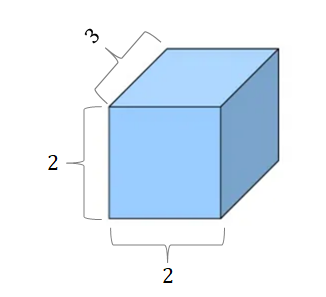

5-1) 3차원 텐서에서 2차원 텐서로 변경

In [80]:
print(ft.view([-1, 3])) # ft라는 텐서를 (?, 3)의 크기로 변경
print(ft.view([-1, 3]).shape)

tensor([[ 0.,  1.,  2.],
        [ 3.,  4.,  5.],
        [ 6.,  7.,  8.],
        [ 9., 10., 11.]])
torch.Size([4, 3])


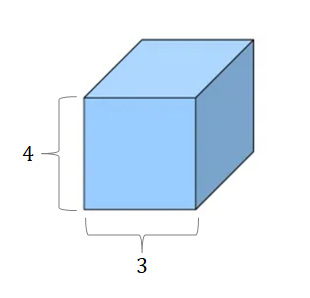

내부적으로 크기 변환은 다음과 같이 이루어진다.
```
(2,2,3) -> (2x2, 3) -> (4, 3)
```

<규칙>
1. view 는 기본적으로 변경 전과 변경 후의 텐서 안의 원소 개수가 유지되어야 한다.
2. 파이토치의 view는 사이즈가 -1로 설정되면 다른 차원으로부터 해당 값을 유추한다.

5-2) 3차원 텐서의 크기 변경
- 3차원 텐서에서 3차원 텐서로 차원은 유지하되, 크기를 바꾸는 작업

In [83]:
print(ft)

tensor([[[ 0.,  1.,  2.],
         [ 3.,  4.,  5.]],

        [[ 6.,  7.,  8.],
         [ 9., 10., 11.]]])


In [81]:
# (2 x 2 x 3) = (? x 1 x 3) = 12 -> ? = 4
print(ft.view([-1,  1, 3]))
print(ft.view([-1, 1, 3]).shape)

tensor([[[ 0.,  1.,  2.]],

        [[ 3.,  4.,  5.]],

        [[ 6.,  7.,  8.]],

        [[ 9., 10., 11.]]])
torch.Size([4, 1, 3])


6) 스퀴즈(Squeeze) - 1인 차원을 제거한다.
- 차원이 1인 경우에는 해당 차원을 제거하는 것

In [84]:
# (3 x 1) 의 크기를 가지는 2차원 텐서
ft = torch.FloatTensor([
    [0],
    [1],
    [2]
])

print(ft)
print(ft.shape)

tensor([[0.],
        [1.],
        [2.]])
torch.Size([3, 1])


In [85]:
print(ft.squeeze())
print(ft.squeeze().shape)

tensor([0., 1., 2.])
torch.Size([3])


- 1차원 벡터가 된 것을 확인할 수 있다.

7) 언스퀴즈(Unsqueeze) - 특정 위치에 1인 차원을 추가한다.

In [88]:
# 차원이 1개인 1원 벡터 선언
ft = torch.FloatTensor(
    [0, 1, 2]
)

print(ft.shape)

torch.Size([3])


In [92]:
print(ft.unsqueeze(0)) # 0을 인자로 넣으면 첫번째 차원에 1인 차원이 추가됨. (3, ) -> (1, 3)
print(ft.unsqueeze(0).shape)

tensor([[0., 1., 2.]])
torch.Size([1, 3])


In [94]:
# view를 통해서도 구현이 가능하다.
print(ft.view(1, -1))
print(ft.view(1, -1).shape)

tensor([[0., 1., 2.]])
torch.Size([1, 3])


In [96]:
 # 인자로 1 사용
print(ft.unsqueeze(1)) # 1을 인자로 넣으면 두번째 차원에 1을 추가하겠다는 것을 의미 (3, ) -> (3, 1)
print(ft.unsqueeze(1).shape)

tensor([[0.],
        [1.],
        [2.]])
torch.Size([3, 1])


In [98]:
# 인자로 -1 사용
print(ft.unsqueeze(-1)) # 인덱스 상으로 마지막 차원을 의미함.
print(ft.unsqueeze(-1).shape)

tensor([[0.],
        [1.],
        [2.]])
torch.Size([3, 1])


`view()`, `squeeze()`, `unsqueeze()`는 텐서의 원소 수를 그대로 유지하면서 모양과 차원을 조절

8) 타입 캐스팅(Type Casting)

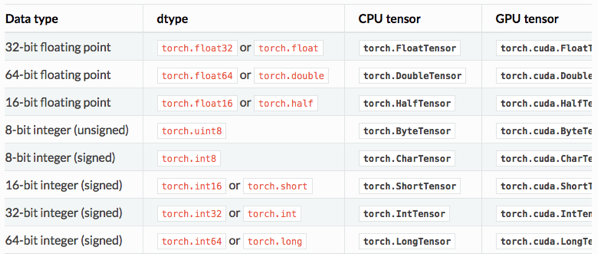

- 텐서에는 각 데이터형별로 자료형이 정의되어 있음.
- 예시: `torch.cuba.FloatTensor`- GPU 연산을 위한 자료형
- 타입캐스팅은 이러한 자료형을 변환하는 것을 뜻함

In [99]:
lt = torch.LongTensor([1,2, 3, 4])
print(lt)

tensor([1, 2, 3, 4])


In [100]:
# 텐서에 .float()를 붙이면 float형으로 타입이 변경됨
print(lt.float())

tensor([1., 2., 3., 4.])


In [101]:
# Byte 타입의 텐서
bt = torch.ByteTensor([True, False, False, True])
print(bt)

tensor([1, 0, 0, 1], dtype=torch.uint8)


In [102]:
# .long 하면 long 타입의 텐서로 변경됨.
# .float 하면 float 타입의 텐서로 변경됨.

print(bt.long())
print(bt.float())

tensor([1, 0, 0, 1])
tensor([1., 0., 0., 1.])


9) 연결하기(concatenate)

- 두 텐서를 연결하기

In [110]:
x = torch.FloatTensor([[1, 2], [3, 4]])
y = torch.FloatTensor([[5, 6], [7, 8]])
print(x)
print(y)

tensor([[1., 2.],
        [3., 4.]])
tensor([[5., 6.],
        [7., 8.]])


- `torch.cat`은 어느 차원을 늘릴 것인지를 인자로 줄 수 있음

In [107]:
# dim=0 - 행을 늘리고 싶다.
print(torch.cat([x, y], dim=0))

tensor([[1., 2.],
        [3., 4.],
        [5., 6.],
        [7., 8.]])


In [108]:
# dim=1 - 열을 늘리고 싶다.
print(torch.cat([x, y], dim=1))

tensor([[1., 2., 5., 6.],
        [3., 4., 7., 8.]])


10) 스택킹(Stacking)

In [113]:
# 크기가 (2, )로 동일한 3개의 벡터 생성
x = torch.FloatTensor([1, 4])
y = torch.FloatTensor([2, 5])
z = torch.FloatTensor([3, 6])

In [116]:
# torch.stack 을 통해 3개의 벡터를 모두 스택킹하기
print(torch.stack([x, y, z]))

tensor([[1., 4.],
        [2., 5.],
        [3., 6.]])


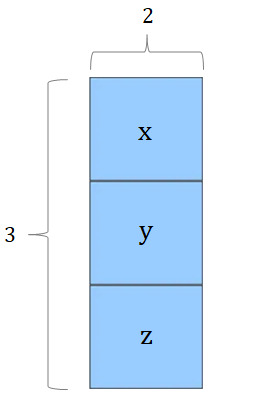

In [117]:
# 동일한 작업을 unsqueeze로 수행하기
print(torch.cat([x.unsqueeze(0), y.unsqueeze(0), z.unsqueeze(0)], dim=0))

tensor([[1., 4.],
        [2., 5.],
        [3., 6.]])


- `unsqueeze(0)`을 하므로 3개의 벡터가 (2,) -> (1, 2)로 텐서의 크기가 변경됨.
- 여기에 cat을 사용므로 (3x2) 텐서가 된다.

In [118]:
# dim=1 을 인자로 주는 경우
print(torch.stack([x, y, z], dim=1))

tensor([[1., 2., 3.],
        [4., 5., 6.]])


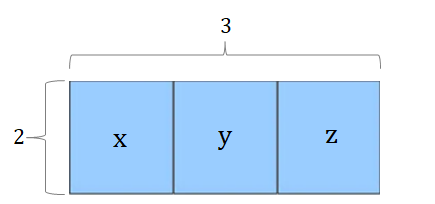

11) ones_like와 zeros_like - 0으로 채워진 텐서와 1로 채워진 텐서

In [119]:
# (2 x 3) 텐서 생성
x = torch.FloatTensor([[0, 1, 2], [2, 1, 0]])
print(x)

tensor([[0., 1., 2.],
        [2., 1., 0.]])


In [121]:
# ones_like - 동일한 크기지만 1으로만 값이 채워진 텐서 생성
print(torch.ones_like(x))

tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [122]:
# zeros_like - 동일한 크기지만 0으로만 값이 채워진 텐서 생성
print(torch.zeros_like(x))

tensor([[0., 0., 0.],
        [0., 0., 0.]])


12) In-place Operation (덮어쓰기 연산)

In [128]:
# (2x2) 텐서를 만들고 x에 저장
x = torch.FloatTensor([[1, 2], [3, 4]])

In [129]:
# 곱하기 연산
print(x.mul(2.))
print(x)

tensor([[2., 4.],
        [6., 8.]])
tensor([[1., 2.],
        [3., 4.]])


- 기존의 값은 변하지 않은 것을 볼 수 있음

- 연산 뒤에 _ 를 붙이면 기존의 값을 덮어쓰기함.

In [131]:
print(x.mul_(2.))
print(x)

tensor([[ 4.,  8.],
        [12., 16.]])
tensor([[ 4.,  8.],
        [12., 16.]])
